In [1]:
#! pip install --upgrade --force-reinstall mediapipe

In [2]:
# import zipfile
# import os

# zip_path = "CCDEPLRL_MidtermsP2_Data.zip"
# extract_path = "CCDEPLRL_MidtermsP2_Data"

# # Make sure the output directory exists
# os.makedirs(extract_path, exist_ok=True)

# # Extract the zip file
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Unzip complete!")

In [3]:
# import shutil

# folder_path = "unzipped_data"

# if os.path.exists(folder_path):
#     shutil.rmtree(folder_path)
#     print("Folder deleted.")
# else:
#     print("Folder not found.")

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import cv2
import mediapipe as mp
from tqdm import tqdm

In [5]:
SOURCE_DIR = "CCDEPLRL_MidtermsP2_Data"
OUTPUT_DIR = "CCDEPLRL_MidtermsP2_Data_Cropped"
IMG_SIZE = 128

# Initialize Mediapipe face detector
mp_face_detection = mp.solutions.face_detection
face_detector = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.9)

# Prepare output directories
splits = ["Train", "Validation", "Test"]
for split in splits:
    for class_name in os.listdir(os.path.join(SOURCE_DIR, split)):
        os.makedirs(os.path.join(OUTPUT_DIR, split, class_name), exist_ok=True)

# Crop faces and save resized output
for split in splits:
    for class_name in os.listdir(os.path.join(SOURCE_DIR, split)):
        input_dir = os.path.join(SOURCE_DIR, split, class_name)
        output_dir = os.path.join(OUTPUT_DIR, split, class_name)

        for file in tqdm(os.listdir(input_dir), desc=f"Processing {split}/{class_name}"):
            file_path = os.path.join(input_dir, file)
            img = cv2.imread(file_path)
            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            result = face_detector.process(img_rgb)

            if result.detections:
                det = result.detections[0]
                bbox = det.location_data.relative_bounding_box
                h, w, _ = img.shape
                x = int(bbox.xmin * w)
                y = int(bbox.ymin * h)
                bw = int(bbox.width * w)
                bh = int(bbox.height * h)

                pad = 20
                x1 = max(x - pad, 0)
                y1 = max(y - pad, 0)
                x2 = min(x + bw + pad, w)
                y2 = min(y + bh + pad, h)

                face_crop = img[y1:y2, x1:x2]
                resized_crop = cv2.resize(face_crop, (IMG_SIZE, IMG_SIZE))
                out_path = os.path.join(output_dir, file)
                cv2.imwrite(out_path, resized_crop)

Processing Test/Jessy: 100%|██████████| 40/40 [00:01<00:00, 35.46it/s]


In [6]:
img_height, img_width = 128, 128
batch_size = 10

In [7]:
base_path = "CCDEPLRL_MidtermsP2_Data_Cropped"

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/Train",
    image_size=(img_height, img_width),
    batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/Validation",
    image_size=(img_height, img_width),
    batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/Test",
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 533 files belonging to 4 classes.
Found 82 files belonging to 4 classes.
Found 155 files belonging to 4 classes.


In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

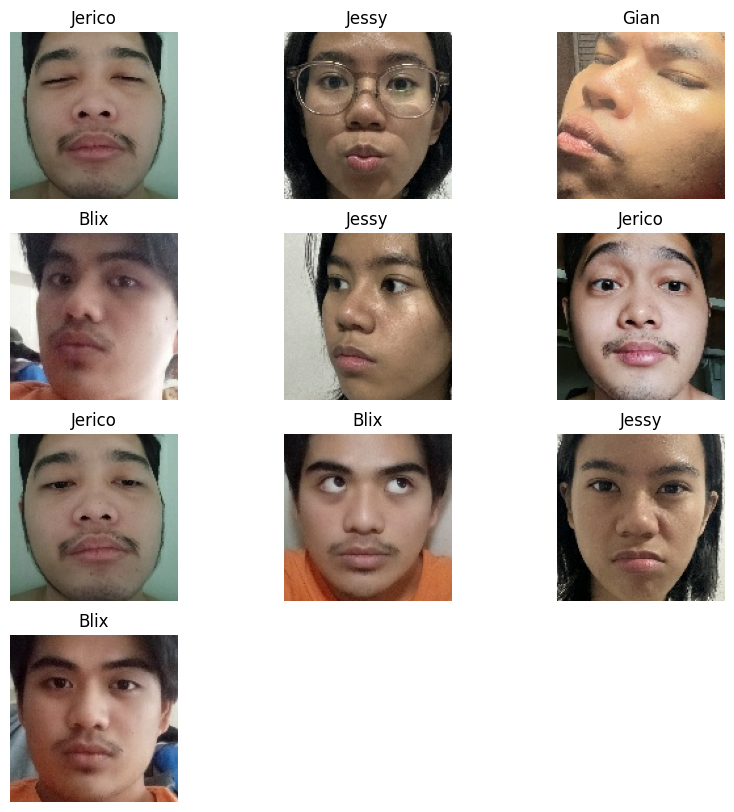

In [9]:
class_names = ["Blix", "Gian", "Jerico", "Jessy"]

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
  for i in range(batch_size):
    ax = plt.subplot(4, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
     

In [40]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3), include_top=False, weights='imagenet')
base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomHeight(0.1),
    tf.keras.layers.RandomWidth(0.1),       
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])



In [41]:
# model = tf.keras.Sequential([
#     tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
#     data_augmentation,

#     tf.keras.layers.Conv2D(32, 3, activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.Conv2D(64, 3, activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.Conv2D(128, 3, activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.GlobalAveragePooling2D(),
#     tf.keras.layers.Dropout(0.4),
#     tf.keras.layers.Dense(128, activation='relu'),
#     tf.keras.layers.Dense(4, activation = 'softmax')  # Final classification layer
# ])


# model = tf.keras.Sequential([
#     tf.keras.layers.Rescaling(1./255),
#     data_augmentation,
#     base_model,
#     tf.keras.layers.GlobalAveragePooling2D(),
#     tf.keras.layers.Dense(128, activation='relu'),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(4, activation='softmax')  # 4 classes
# Add BatchNormalization and Dropout layers to improve generalization
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation='softmax')  # 4 classes
])



c:\Users\Coli\miniconda3\envs\myenv\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard
     

In [52]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True,
    verbose=1,
    min_delta=0.0001,
    start_from_epoch=5
)
     

In [54]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # Reduce LR by half
    patience=5,        # Wait 3 epochs before reducing
    min_lr=1e-6,       # Don't go below this
    min_delta=0.0001,
    verbose=1
)


In [55]:
initial_learning_rate = 0.000001
optimizer = tf.keras.optimizers.Adam(learning_rate=initial_learning_rate)

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)


In [56]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 1000,
    callbacks = [early_stop, reduce_lr]
)

Epoch 1/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step - accuracy: 0.2560 - loss: 1.5500 - val_accuracy: 0.2927 - val_loss: 2.0258 - learning_rate: 0.0010
Epoch 2/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.2654 - loss: 1.5064 - val_accuracy: 0.2561 - val_loss: 1.8493 - learning_rate: 0.0010
Epoch 3/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.2489 - loss: 1.5492 - val_accuracy: 0.2439 - val_loss: 2.5527 - learning_rate: 0.0010
Epoch 4/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.2880 - loss: 1.4639 - val_accuracy: 0.2561 - val_loss: 2.5210 - learning_rate: 0.0010
Epoch 5/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.2626 - loss: 1.4895 - val_accuracy: 0.2439 - val_loss: 2.3577 - learning_rate: 0.0010
Epoch 6/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.2819 - loss: 1.4183 - val_accuracy: 0.2439 - val_loss: 3.4557 - learning_rate: 0.0010
Epoch 7/1000
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.2796 - 

In [48]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 12)) # Unpack into ax1 and ax2
  ax1.legend(['train', 'validation'], loc='upper left') # Call legend on ax1
  ax1.plot(history.history['loss']) # Plot on ax1
  ax1.plot(history.history['val_loss']) # Plot on ax1
  ax1.set_title('model loss') # Set title on ax1
  ax1.set_ylabel('loss') # Set label on ax1
  ax1.set_xlabel('epoch') # Set label on ax1
  ax2.legend(['train', 'validation'], loc='upper left') # Call legend on ax2
  ax2.plot(history.history['accuracy']) # Plot on ax2
  ax2.plot(history.history['val_accuracy']) # Plot on ax2
  ax2.set_title('model accuracy') # Set title on ax2
  ax2.set_ylabel('accuracy') # Set label on ax2
  ax2.set_xlabel('epoch') # Set label on ax2
  plt.show() # Show the plot

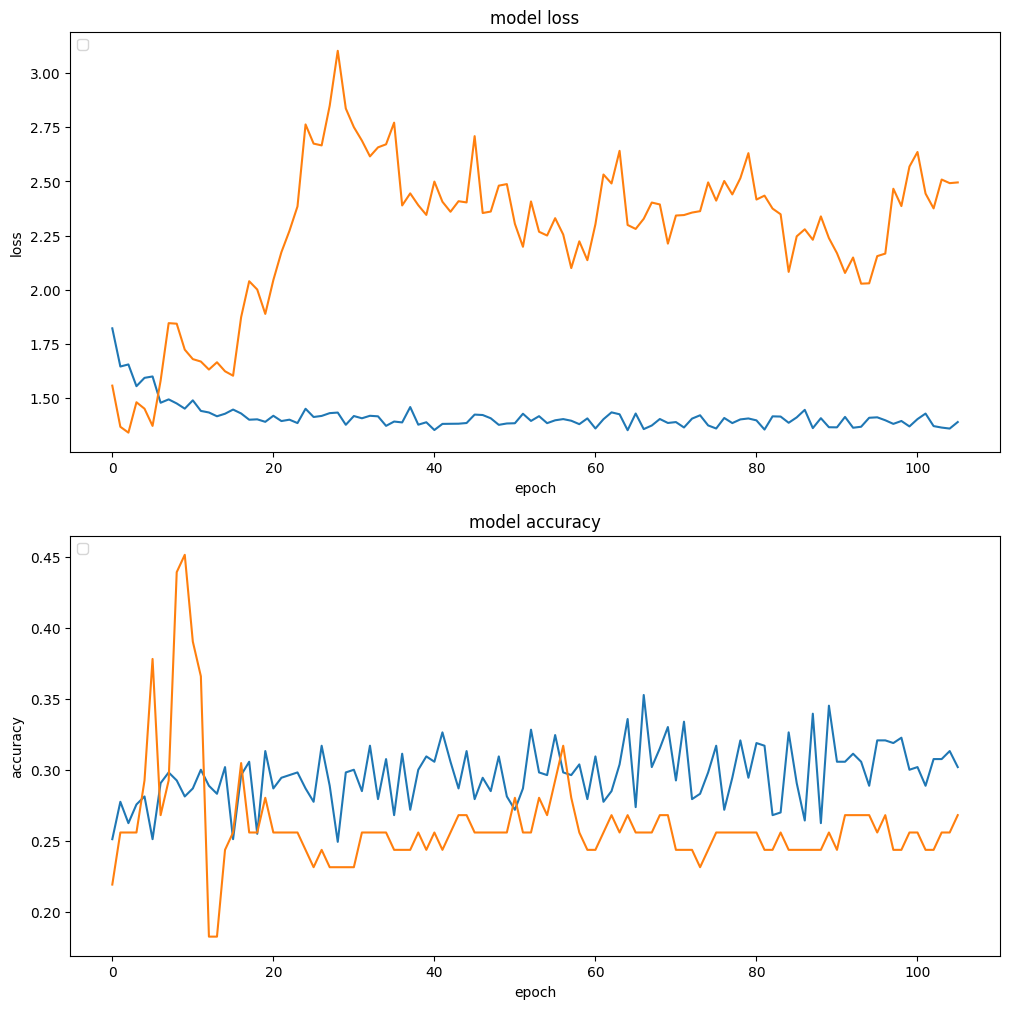

In [49]:
plot_history(history)

In [50]:
model.evaluate(test_ds)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.3771 - loss: 1.3210


[1.4059925079345703, 0.3290322721004486]

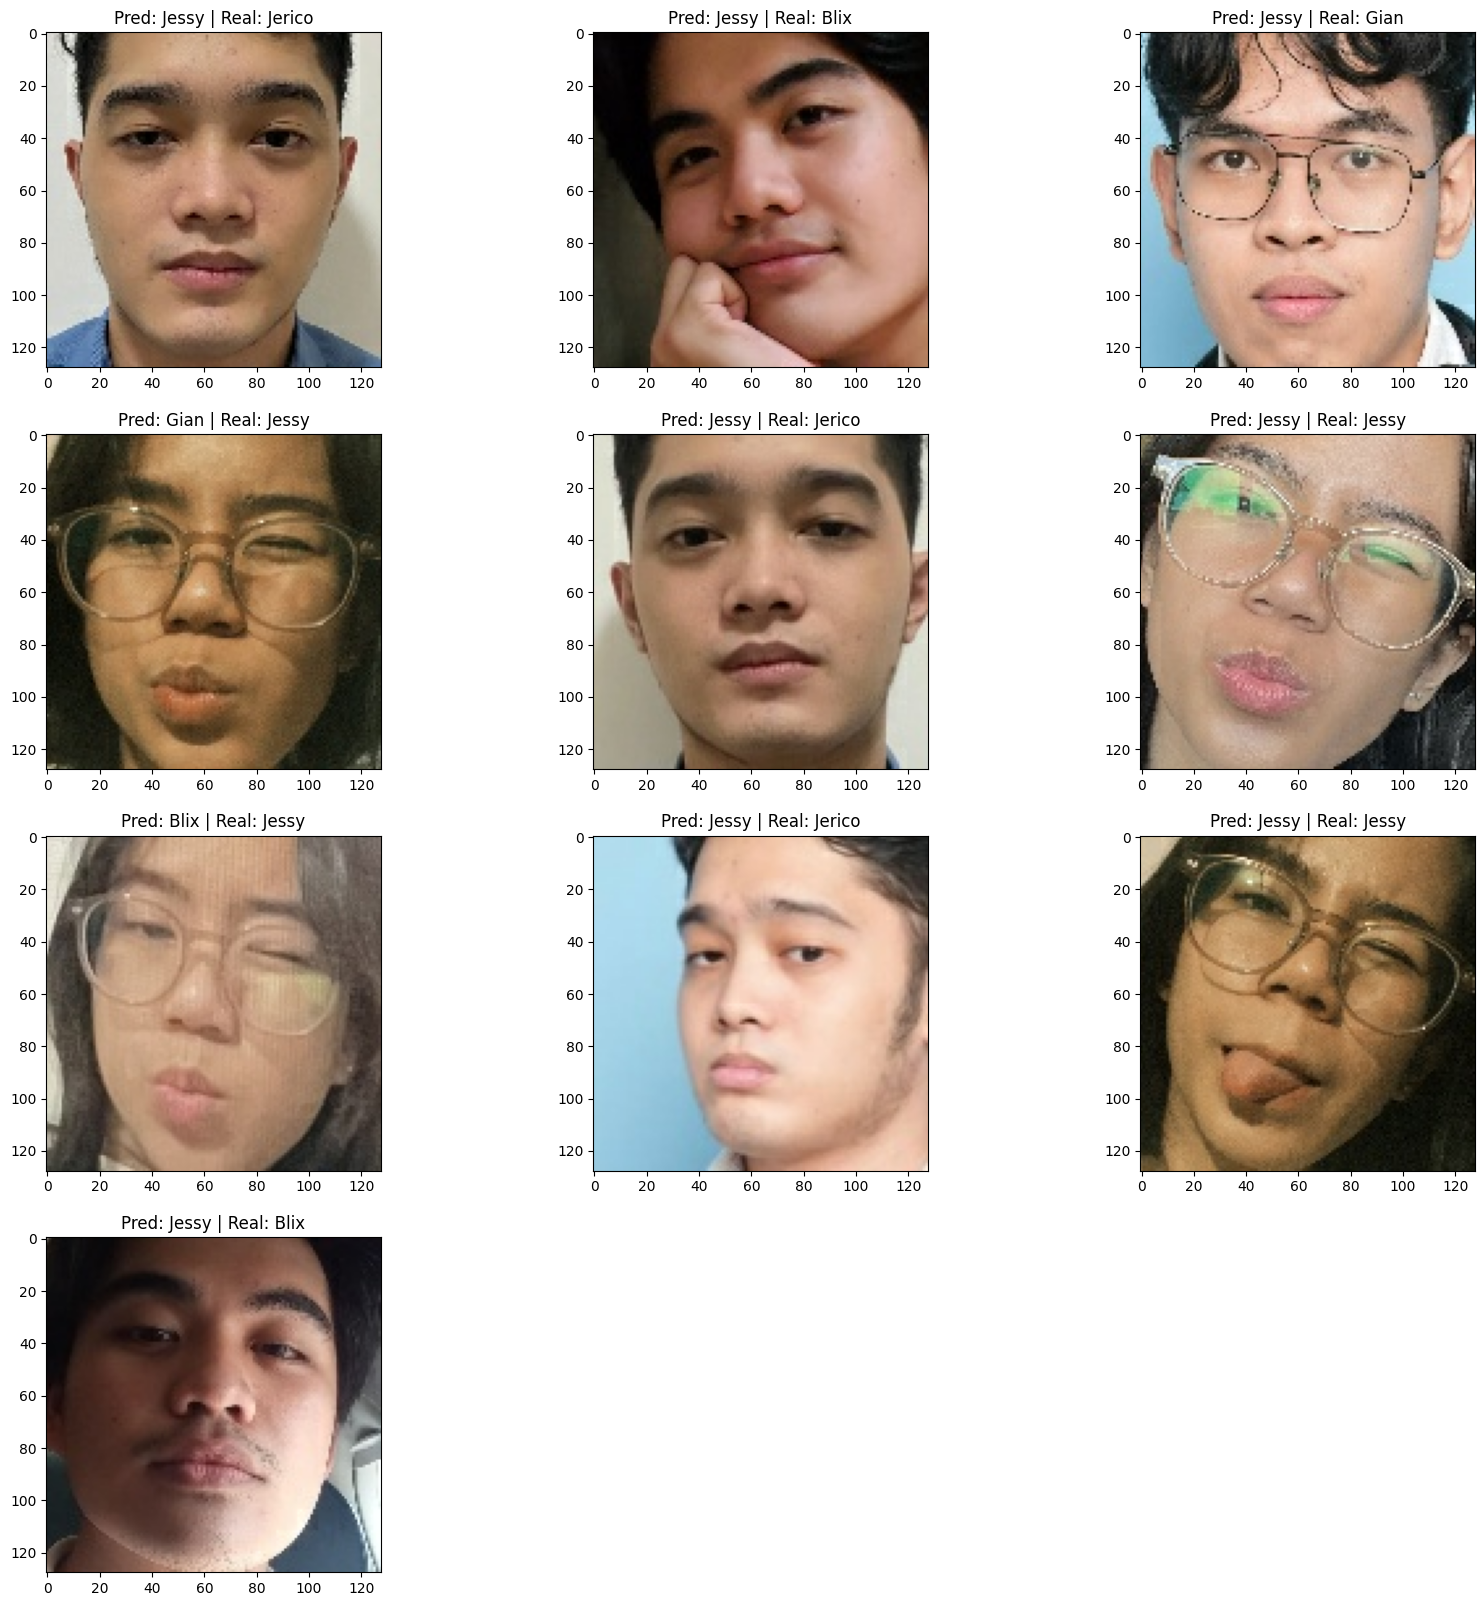

In [27]:
import numpy

plt.figure(figsize=(20,20))
for images, labels in test_ds.take(1):
  classifications = model(images)
  # print(classifications)

  for i in range(batch_size):
    ax = plt.subplot(4, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index = numpy.argmax(classifications[i])
    plt.title("Pred: " + class_names[index] + " | Real: " + class_names[labels[i]])

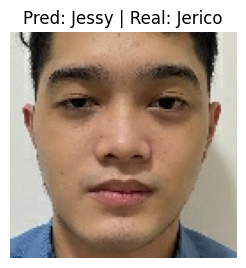

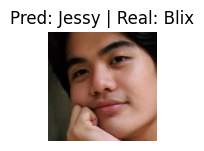

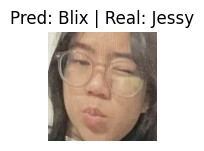

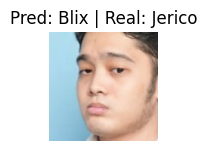

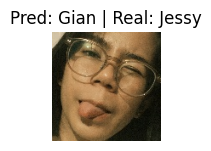

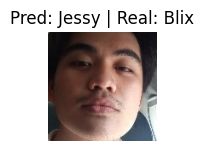

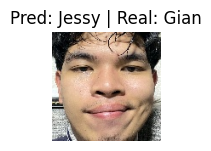

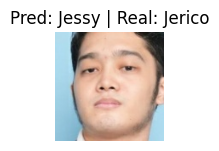

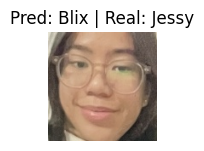

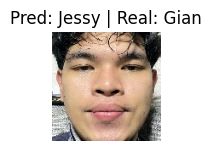

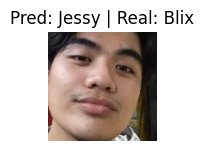

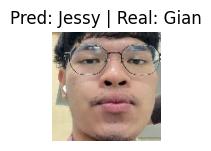

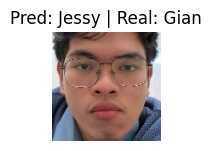

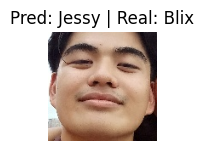

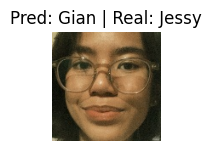

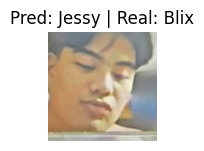

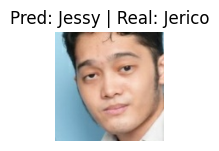

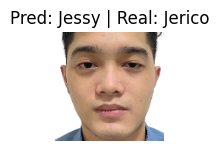

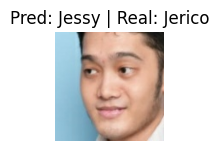

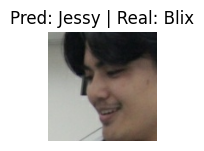

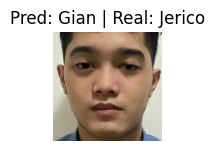

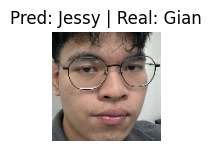

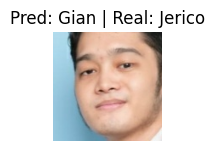

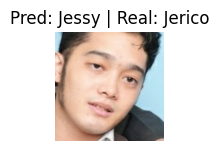

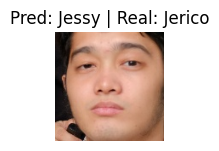

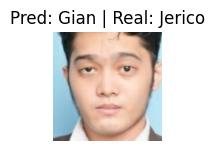

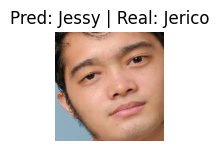

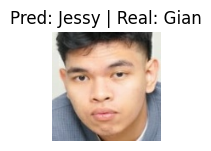

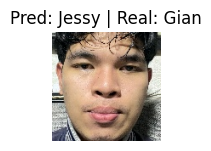

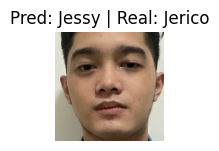

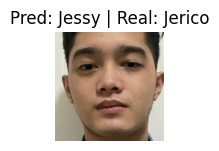

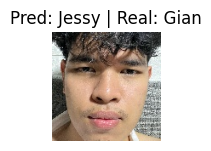

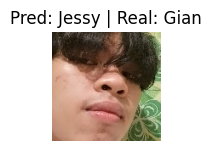

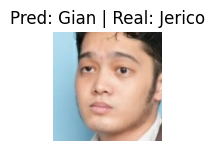

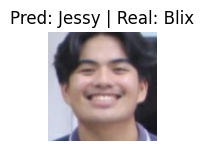

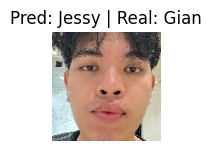

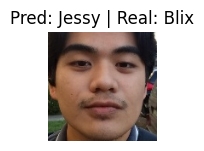

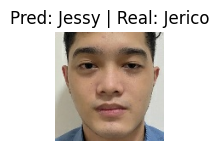

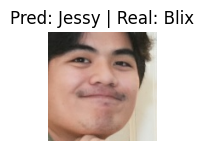

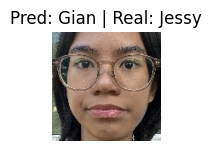

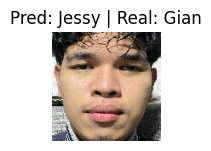

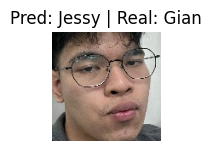

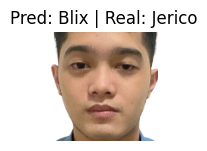

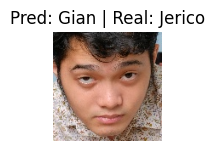

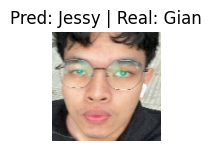

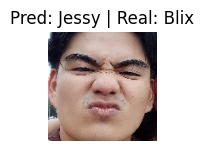

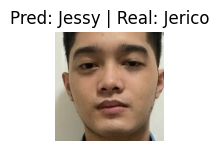

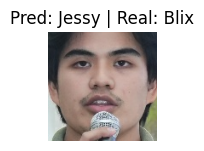

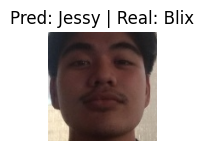

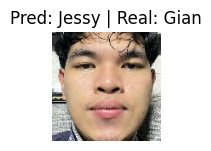

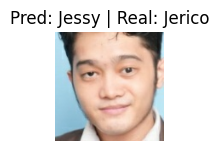

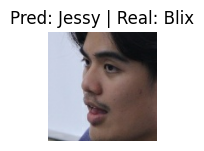

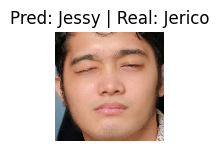

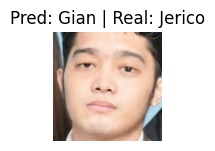

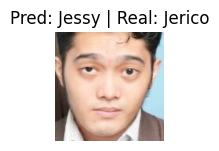

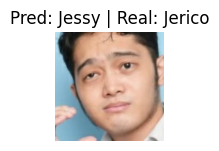

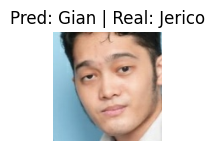

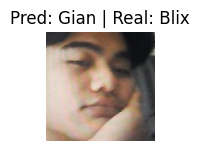

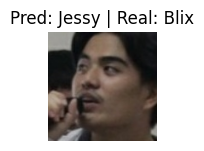

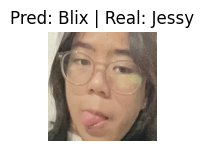

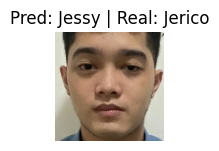

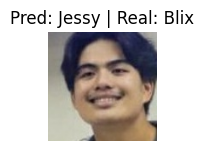

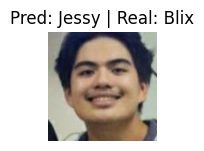

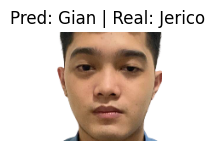

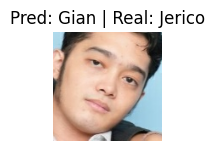

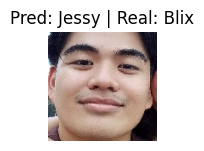

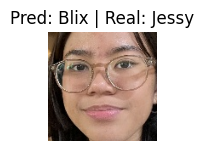

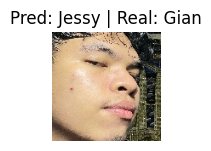

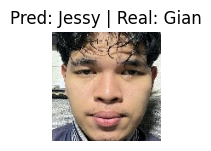

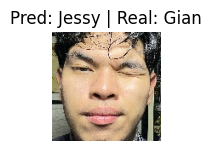

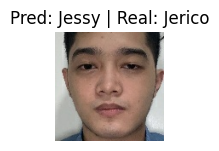

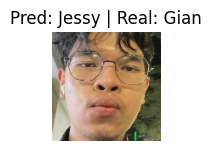

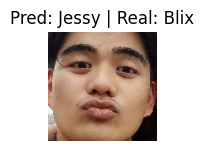

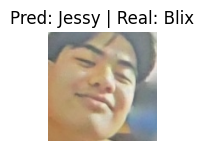

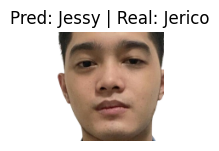

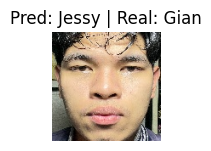

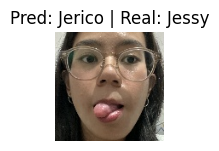

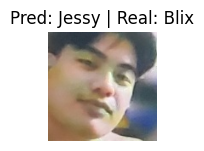

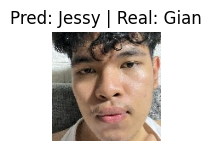

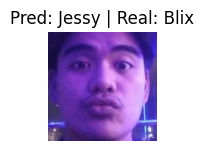

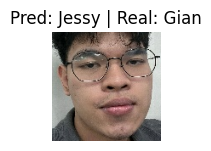

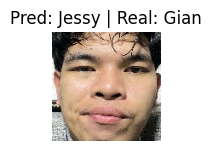

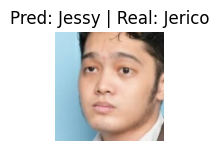

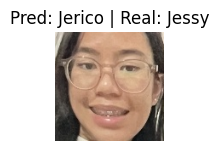

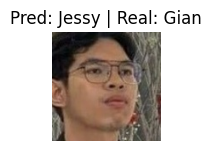

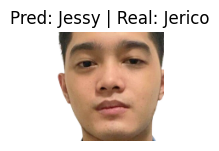

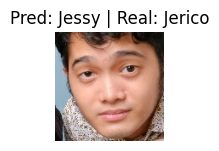

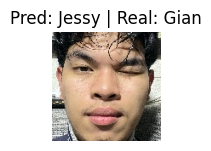

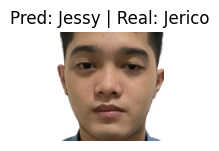

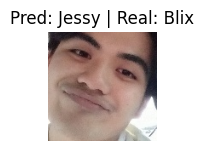

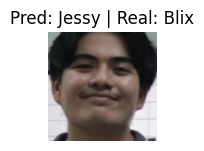

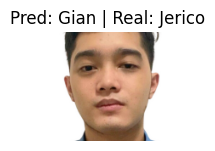

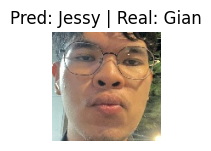

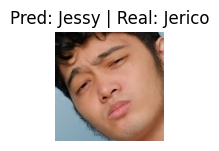

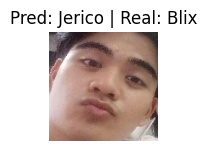

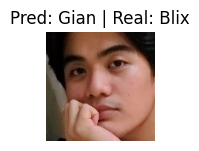

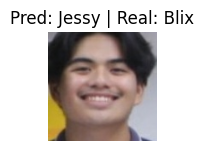

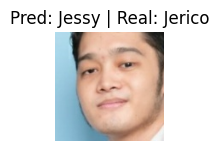

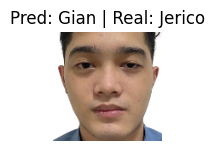

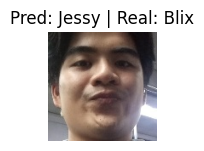

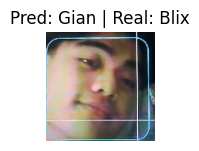

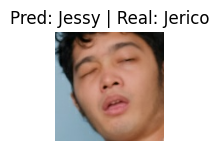

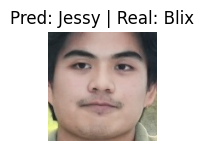

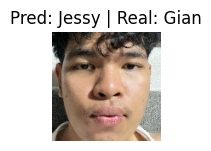

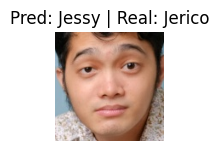

In [21]:
# Plot images where model misclassified
plt.figure(figsize=(10,10))
for images, labels in test_ds:
  classifications = model(images)
  predictions = classifications.numpy().argmax(axis=1)
  misclassified_indices = numpy.where(predictions != labels)[0]
  for i, index in enumerate(misclassified_indices[:9]):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[index].numpy().astype("uint8"))
    plt.title("Pred: " + class_names[predictions[index]] + " | Real: " + class_names[labels[index]])
    plt.axis("off")
    plt.show()

In [22]:
! pip install scikit-learn

In [23]:
from sklearn.metrics import classification_report
y_true = []
y_pred = []

for images, labels in test_ds:
  classifications = model(images)
  predictions = classifications.numpy().argmax(axis=1)
  y_true.extend(labels.numpy())
  y_pred.extend(predictions)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        Blix       0.40      0.16      0.23        37
        Gian       0.32      0.30      0.31        37
      Jerico       0.11      0.02      0.04        41
       Jessy       0.25      0.60      0.35        40

    accuracy                           0.27       155
   macro avg       0.27      0.27      0.23       155
weighted avg       0.27      0.27      0.23       155

